In [1]:
!pip install -q importlib_resources

In [1]:
!pip install -U tensorflow-datasets

In [1]:
!pip install -U "protobuf>=5.28" tensorflow-datasets

  Using cached protobuf-7.36.2-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)


In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [4]:
SEED = 42
IMG = 224
BATCH = 32
TRAIN_FRAC = 0.8
VAL_FRAC = 0.1        # test gets whatever is left (0.1)

tf.keras.utils.set_random_seed(SEED)

In [3]:
ds, info = tfds.load("malaria", split="train", as_supervised=True, with_info=True)
print(info.features["label"].names)
print(info.splits["train"].num_examples)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.R87WWE_1.0.0/malaria-train.tfrecord-[0-9][0-9][0-9][0-9…

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.
['parasitized', 'uninfected']
27558


In [5]:
names = info.features["label"].names
INFECTED = names.index("parasitized")
print("parasitized has index", INFECTED)

parasitized has index 0


In [6]:
n = info.splits["train"].num_examples
n_train = int(TRAIN_FRAC * n)
n_val = int(VAL_FRAC * n)
n_test = n - n_train - n_val
print(n_train, n_val, n_test)

22046 2755 2757


In [8]:
shuffled = ds.shuffle(n, seed=SEED, reshuffle_each_iteration=False)

train_raw = shuffled.take(n_train)
val_raw = shuffled.skip(n_train).take(n_val)
test_raw = shuffled.skip(n_train + n_val)

In [9]:
def prep(img, label):
    img = tf.image.resize(img, (IMG, IMG))
    label = tf.cast(tf.equal(label, INFECTED), tf.float32)
    return img, label

In [10]:
def make_ds(raw, training=False):
    d = raw.map(prep, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        d = d.shuffle(2048, seed=SEED)
    return d.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_raw, training=True)
val_ds = make_ds(val_raw)
test_ds = make_ds(test_raw)

In [11]:
labels = {}
for name, d in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    ys = np.concatenate([y.numpy() for _, y in d]).astype(int)
    labels[name] = ys
    print(name, len(ys), f"infected: {ys.mean():.1%}")
print("total:", sum(len(v) for v in labels.values()), "expected:", n)

train 22046 infected: 50.0%
val 2755 infected: 49.9%
test 2757 infected: 50.1%
total: 27558 expected: 27558


In [12]:
t = labels["test"]
print(len(t), t[:50].tolist(), t.sum())

2757 [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1] 1381


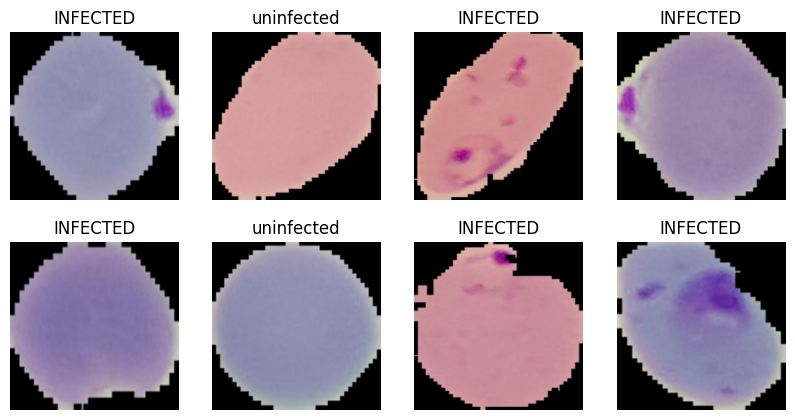

In [13]:
imgs, ys = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, im, y in zip(axes.ravel(), imgs[:8], ys[:8]):
    ax.imshow(im.numpy().astype("uint8"))
    ax.set_title("INFECTED" if y == 1 else "uninfected")
    ax.axis("off")
plt.show()